In [67]:
#Load files from sample_data
from pathlib import Path
import pandas as pd

DATA = Path("/content/sample_data")

if not DATA.exists():
    raise FileNotFoundError("The sample_data folder does not exist.")

print("Files found:")
for file in sorted(DATA.iterdir()):
    print(file.name)

Files found:
.ipynb_checkpoints
SCREENING_CASE_BRIEF_v2.md
appointments.csv
call_logs.csv
finance_monthly_reconciliation.xlsx
inspections.csv
inspector_roster_capacity.csv
inspectors.csv
lead_utm_backfill.csv
leads.csv
marketing_spend.csv
offers_purchases.csv
price_revisions.csv


In [68]:
#Load all datasets
appointments = pd.read_csv(DATA / "appointments.csv")
call_logs = pd.read_csv(DATA / "call_logs.csv")
inspections = pd.read_csv(DATA / "inspections.csv")
inspector_roster = pd.read_csv(DATA / "inspector_roster_capacity.csv")
inspectors = pd.read_csv(DATA / "inspectors.csv")
lead_utm = pd.read_csv(DATA / "lead_utm_backfill.csv")
leads = pd.read_csv(DATA / "leads.csv")
marketing_spend = pd.read_csv(DATA / "marketing_spend.csv")
offers_purchases = pd.read_csv(DATA / "offers_purchases.csv")
price_revisions = pd.read_csv(DATA / "price_revisions.csv")

finance = pd.read_excel(
    DATA / "finance_monthly_reconciliation.xlsx",
    sheet_name="Finance Counts"
)

brief = (DATA / "SCREENING_CASE_BRIEF_v2.md").read_text(
    encoding="utf-8"
)

print("All files loaded successfully.")

All files loaded successfully.


In [69]:
#Check row counts
datasets = {
    "leads": leads,
    "lead_utm": lead_utm,
    "call_logs": call_logs,
    "appointments": appointments,
    "inspections": inspections,
    "inspector_roster": inspector_roster,
    "inspectors": inspectors,
    "marketing_spend": marketing_spend,
    "offers_purchases": offers_purchases,
    "price_revisions": price_revisions,
    "finance": finance,
}

for name, df in datasets.items():
    print(f"{name:25} rows={len(df):,}, columns={len(df.columns)}")

leads                     rows=50,812, columns=6
lead_utm                  rows=6,097, columns=2
call_logs                 rows=50,812, columns=4
appointments              rows=21,553, columns=6
inspections               rows=17,135, columns=12
inspector_roster          rows=552, columns=6
inspectors                rows=211, columns=5
marketing_spend           rows=483, columns=3
offers_purchases          rows=13,510, columns=7
price_revisions           rows=8,376, columns=5
finance                   rows=4, columns=3


In [70]:
#Check columns
for name, df in datasets.items():
    print(f"\n{name.upper()}")
    print(list(df.columns))


LEADS
['lead_id', 'created_at', 'city', 'source', 'car_year', 'phone']

LEAD_UTM
['lead_id', 'utm_source']

CALL_LOGS
['lead_id', 'call_attempts', 'connected', 'talk_time_sec']

APPOINTMENTS
['appointment_id', 'lead_id', 'inspector_id', 'scheduled_at', 'status', 'hours_to_slot']

INSPECTIONS
['inspection_id', 'lead_id', 'inspector_id', 'started_at', 'completed_at', 'duration_min', 'seller_lat', 'seller_lng', 'inspection_lat', 'inspection_lng', 'quoted_price', 'source_system']

INSPECTOR_ROSTER
['city', 'date', 'inspectors_rostered', 'slot_capacity', 'shift_start', 'shift_end']

INSPECTORS
['inspector_id', 'city', 'employment_type', 'onboarded_on', 'hub']

MARKETING_SPEND
['date', 'channel', 'spend_inr']

OFFERS_PURCHASES
['lead_id', 'inspection_id', 'offer_price', 'purchased', 'refurb_cost', 'tow_cost', 'resale_price']

PRICE_REVISIONS
['inspection_id', 'initial_quote', 'revised_offer', 'revision_pct', 'revision_reason']

FINANCE
['month', 'finance_inspection_count', 'note']


#Clean dates, timezones, and duplicate records


In [71]:
#Create clean copies
leads_clean = leads.copy()
inspections_clean = inspections.copy()
appointments_clean = appointments.copy()
calls_clean = call_logs.copy()
offers_clean = offers_purchases.copy()
revisions_clean = price_revisions.copy()

In [72]:
#Parse date columns
leads_clean["created_at"] = pd.to_datetime(
    leads_clean["created_at"],
    format="mixed",
    dayfirst=True,
    errors="coerce"
)

appointments_clean["scheduled_at"] = pd.to_datetime(
    appointments_clean["scheduled_at"],
    format="mixed",
    errors="coerce"
)

inspections_clean["started_at"] = pd.to_datetime(
    inspections_clean["started_at"],
    format="mixed",
    errors="coerce"
)

inspections_clean["completed_at"] = pd.to_datetime(
    inspections_clean["completed_at"],
    format="mixed",
    errors="coerce"
)

inspectors_clean = inspectors.copy()
inspectors_clean["onboarded_on"] = pd.to_datetime(
    inspectors_clean["onboarded_on"],
    format="mixed",
    errors="coerce"
)

marketing_spend_clean = marketing_spend.copy()
marketing_spend_clean["date"] = pd.to_datetime(
    marketing_spend_clean["date"],
    format="mixed",
    errors="coerce"
)

inspector_roster_clean = inspector_roster.copy()
inspector_roster_clean["date"] = pd.to_datetime(
    inspector_roster_clean["date"],
    format="mixed",
    errors="coerce"
)

In [73]:
#Correct inspection timezones
inspections_clean["completed_ist"] = inspections_clean["completed_at"]
inspections_clean["started_ist"] = inspections_clean["started_at"]

utc_mask = inspections_clean["source_system"].eq(
    "FIELD_APP_V2 (UTC)"
)

inspections_clean.loc[utc_mask, "completed_ist"] = (
    inspections_clean.loc[utc_mask, "completed_at"]
    + pd.Timedelta(hours=5, minutes=30)
)

inspections_clean.loc[utc_mask, "started_ist"] = (
    inspections_clean.loc[utc_mask, "started_at"]
    + pd.Timedelta(hours=5, minutes=30)
)

print(
    inspections_clean[
        ["source_system", "completed_at", "completed_ist"]
    ].head()
)

        source_system               completed_at              completed_ist
0  FIELD_APP_V1 (IST) 2026-08-27 06:10:42.005229 2026-08-27 06:10:42.005229
1  FIELD_APP_V1 (IST) 2026-06-16 23:28:40.463046 2026-06-16 23:28:40.463046
2  FIELD_APP_V1 (IST) 2026-07-02 04:27:39.506922 2026-07-02 04:27:39.506922
3  FIELD_APP_V1 (IST) 2026-06-02 08:09:35.976625 2026-06-02 08:09:35.976625
4  FIELD_APP_V1 (IST) 2026-08-18 04:03:36.927918 2026-08-18 04:03:36.927918


In [74]:
#Check date ranges
print("Lead dates:")
print(leads_clean["created_at"].min())
print(leads_clean["created_at"].max())

print("\nInspection dates:")
print(inspections_clean["completed_ist"].min())
print(inspections_clean["completed_ist"].max())

print("\nAppointment dates:")
print(appointments_clean["scheduled_at"].min())
print(appointments_clean["scheduled_at"].max())

Lead dates:
2026-06-01 06:06:09
2026-08-31 23:58:00

Inspection dates:
2026-06-01 10:18:21.540743
2026-09-03 03:18:58.856862

Appointment dates:
2026-06-01 09:10:56.614686
2026-09-03 02:45:47.234894


In [75]:
#Check duplicate records
print("Exact duplicate inspection rows:")
print(inspections_clean.duplicated().sum())

print("\nDuplicate inspection IDs:")
print(
    inspections_clean["inspection_id"]
    .duplicated(keep=False)
    .sum()
)

print("\nDuplicate lead IDs:")
print(leads_clean["lead_id"].duplicated().sum())

print("\nDuplicate appointment IDs:")
print(appointments_clean["appointment_id"].duplicated().sum())

Exact duplicate inspection rows:
286

Duplicate inspection IDs:
572

Duplicate lead IDs:
0

Duplicate appointment IDs:
0


In [76]:
#Create a deduplicated inspection table -- Keep one record per inspection_id

inspections_dedup = (
    inspections_clean
    .sort_values(["inspection_id", "completed_ist"])
    .drop_duplicates(
        subset=["inspection_id"],
        keep="first"
    )
    .copy()
)

print("Original inspections:", len(inspections_clean))
print("Deduplicated inspections:", len(inspections_dedup))
print(
    "Removed rows:",
    len(inspections_clean) - len(inspections_dedup)
)

Original inspections: 17135
Deduplicated inspections: 16849
Removed rows: 286


In [77]:
#Check missing values
for name, df in {
    "leads": leads_clean,
    "inspections": inspections_clean,
    "appointments": appointments_clean,
    "calls": calls_clean,
    "offers": offers_clean,
    "revisions": revisions_clean,
}.items():
    print(f"\n--- {name.upper()} ---")
    missing = df.isna().sum()
    print(missing[missing > 0])


--- LEADS ---
source      6097
car_year    1524
dtype: int64

--- INSPECTIONS ---
Series([], dtype: int64)

--- APPOINTMENTS ---
Series([], dtype: int64)

--- CALLS ---
Series([], dtype: int64)

--- OFFERS ---
resale_price    7315
dtype: int64

--- REVISIONS ---
Series([], dtype: int64)


In [78]:
#Check whether joins work
print(
    "Inspections with unknown lead IDs:",
    (~inspections_clean["lead_id"].isin(
        leads_clean["lead_id"]
    )).sum()
)

print(
    "Offers with unknown inspection IDs:",
    (~offers_clean["inspection_id"].isin(
        inspections_clean["inspection_id"]
    )).sum()
)

print(
    "Appointments with unknown lead IDs:",
    (~appointments_clean["lead_id"].isin(
        leads_clean["lead_id"]
    )).sum()
)

print(
    "Inspections with unknown inspector IDs:",
    (~inspections_clean["inspector_id"].isin(
        inspectors["inspector_id"]
    )).sum()
)

Inspections with unknown lead IDs: 0
Offers with unknown inspection IDs: 675
Appointments with unknown lead IDs: 0
Inspections with unknown inspector IDs: 0


In [79]:
#From June through August 2026
START_DATE = pd.Timestamp("2026-06-01")
END_DATE = pd.Timestamp("2026-09-01")

leads_period = leads_clean[
    (leads_clean["created_at"] >= START_DATE)
    & (leads_clean["created_at"] < END_DATE)
].copy()

inspections_period = inspections_clean[
    (inspections_clean["completed_ist"] >= START_DATE)
    & (inspections_clean["completed_ist"] < END_DATE)
].copy()

print("Leads in assignment period:", len(leads_period))
print("Inspections in assignment period:", len(inspections_period))


Leads in assignment period: 50812
Inspections in assignment period: 16969


In [80]:
#Add month fields
leads_period["lead_month"] = (
    leads_period["created_at"]
    .dt.to_period("M")
    .astype(str)
)

inspections_dedup["inspection_month"] = (
    inspections_dedup["completed_ist"]
    .dt.to_period("M")
    .astype(str)
)

#A1 — August lead-to-inspection conversion

In [81]:
leads_clean["created_at"] = pd.to_datetime(
    leads_clean["created_at"],
    format="mixed",
    dayfirst=True,
    errors="coerce"
)

inspections_clean["completed_ist"] = pd.to_datetime(
    inspections_clean["completed_ist"],
    format="mixed",
    errors="coerce"
)

inspections_dedup = (
    inspections_clean
    .sort_values(["inspection_id", "completed_ist"])
    .drop_duplicates("inspection_id")
)

leads_clean["lead_month"] = (
    leads_clean["created_at"]
    .dt.to_period("M")
    .astype(str)
)

august_leads = leads_clean[
    leads_clean["lead_month"] == "2026-08"
]

august_inspected = august_leads[
    august_leads["lead_id"].isin(
        inspections_dedup["lead_id"]
    )
]["lead_id"].nunique()

A1 = august_inspected / august_leads["lead_id"].nunique() * 100

print(f"A1: {A1:.2f}%")

A1: 27.37%


#A2 — Unique sellers

In [82]:
A2 = leads_clean["phone"].nunique()

print(f"A2: {A2:,}")

A2: 44,701


#A3 — Duplicate inspection rows


In [83]:
A3 = inspections_clean.duplicated().sum()

print(f"A3: {A3:,}")

A3: 286


#A4 More than 20 km away and shorter than 5 minutes

In [84]:
import numpy as np
def haversine_km(lat1, lon1, lat2, lon2):
    lat1, lon1, lat2, lon2 = map(
        np.radians,
        [lat1, lon1, lat2, lon2]
    )

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = (
        np.sin(dlat / 2) ** 2
        + np.cos(lat1)
        * np.cos(lat2)
        * np.sin(dlon / 2) ** 2
    )

    return 6371.0088 * 2 * np.arcsin(np.sqrt(a))


inspections_clean["distance_km"] = haversine_km(
    inspections_clean["seller_lat"],
    inspections_clean["seller_lng"],
    inspections_clean["inspection_lat"],
    inspections_clean["inspection_lng"]
)

gps_duration_errors = inspections_clean[
    (inspections_clean["distance_km"] > 20)
    & (inspections_clean["duration_min"] < 5)
]

A4 = len(gps_duration_errors)

print(f"A4: {A4:,}")

A4: 406


#A5 — Percentage done by vendor-partner inspectors

In [85]:
errors_with_type = gps_duration_errors.merge(
    inspectors[["inspector_id", "employment_type"]],
    on="inspector_id",
    how="left"
)

errors_with_type["employment_type_clean"] = (
    errors_with_type["employment_type"]
    .astype(str)
    .str.strip()
    .str.lower()
)

A5 = (
    errors_with_type["employment_type_clean"]
    .eq("vendor-partner")
    .mean()
    * 100
)

print(f"A5: {A5:.2f}%")

A5: 100.00%


#A6 — Lucknow call connect rate after 21 July

In [86]:
leads_for_calls = leads_clean[
    ["lead_id", "city", "created_at"]
].merge(
    calls_clean,
    on="lead_id",
    how="inner"
)

lucknow_calls = leads_for_calls[
    (leads_for_calls["city"] == "Lucknow")
    & (
        leads_for_calls["created_at"]
        >= pd.Timestamp("2026-07-22")
    )
]

A6 = lucknow_calls["connected"].mean() * 100

print(f"A6: {A6:.2f}%")

A6: 24.79%


#A7 — Show-up rate when lead-to-slot wait exceeded 48 hours

In [87]:
long_wait_appointments = appointments_clean[
    appointments_clean["hours_to_slot"] > 48
]

A7 = (
    long_wait_appointments["status"]
    .eq("Completed")
    .mean()
    * 100
)

print(f"A7: {A7:.2f}%")

A7: 71.34%


#A8 — Contribution from old cars in Jaipur and Lucknow

In [88]:
START_DATE = pd.Timestamp("2026-06-01")
END_DATE = pd.Timestamp("2026-09-01")

leads_period = leads_clean[
    (leads_clean["created_at"] >= START_DATE)
    & (leads_clean["created_at"] < END_DATE)
].copy()

old_car_data = offers_clean.merge(
    leads_period[
        ["lead_id", "city", "car_year"]
    ],
    on="lead_id",
    how="inner"
)

old_car_purchases = old_car_data[
    (old_car_data["purchased"] == 1)
    & (old_car_data["car_year"] <= 2012)
    & (
        old_car_data["city"]
        .isin(["Jaipur", "Lucknow"])
    )
].copy()

old_car_purchases["contribution"] = (
    old_car_purchases["resale_price"]
    - old_car_purchases["offer_price"]
    - old_car_purchases["refurb_cost"]
    - old_car_purchases["tow_cost"]
)

A8 = old_car_purchases["contribution"].sum()

print(f"A8: ₹{A8:,.0f}")

print("\nContribution by city:")
print(
    old_car_purchases
    .groupby("city")["contribution"]
    .sum()
)

A8: ₹-10,028,551

Contribution by city:
city
Jaipur    -6971980.0
Lucknow   -3056571.0
Name: contribution, dtype: float64


#A9 — Offer rows with invalid inspection IDs

In [89]:
A9 = (
    ~offers_clean["inspection_id"]
    .isin(inspections_clean["inspection_id"])
).sum()

print(f"A9: {A9:,}")

A9: 675


#A10 — Purchase rate after offer revised down by more than 10%

In [90]:
offers_with_revision = offers_clean.merge(
    revisions_clean[
        ["inspection_id", "revision_pct"]
    ].drop_duplicates("inspection_id"),
    on="inspection_id",
    how="left"
)

revised_down = offers_with_revision[
    offers_with_revision["revision_pct"] > 10
]

A10 = revised_down["purchased"].mean() * 100

print(f"A10: {A10:.2f}%")

A10: 16.04%


#A11 — Purchase rate when there was no revision

In [91]:
no_revision = offers_with_revision[
    offers_with_revision["revision_pct"] == 0
]

A11 = no_revision["purchased"].mean() * 100

print(f"A11: {A11:.2f}%")

A11: 69.54%


#A12 — Percentage points of the drop that are not real

In [92]:
cohort_leads = leads_period[
    ["lead_id", "lead_month"]
].drop_duplicates()

inspected_leads = inspections_dedup[
    ["lead_id"]
].drop_duplicates()

cohort_table = (
    cohort_leads
    .assign(
        inspected=cohort_leads["lead_id"].isin(
            inspected_leads["lead_id"]
        )
    )
    .groupby("lead_month")
    .agg(
        leads=("lead_id", "nunique"),
        inspected_leads=("inspected", "sum")
    )
    .reset_index()
)

cohort_table["conversion_pct"] = (
    cohort_table["inspected_leads"]
    / cohort_table["leads"]
    * 100
)

june_conversion = cohort_table.loc[
    cohort_table["lead_month"] == "2026-06",
    "conversion_pct"
].iloc[0]

august_conversion = cohort_table.loc[
    cohort_table["lead_month"] == "2026-08",
    "conversion_pct"
].iloc[0]

observed_drop = june_conversion - august_conversion
headline_drop = 37.5 - 27.4

A12 = headline_drop - observed_drop

print(f"June conversion: {june_conversion:.2f}%")
print(f"August conversion: {august_conversion:.2f}%")
print(f"Observed drop: {observed_drop:.2f} percentage points")
print(f"A12: {A12:.2f} percentage points")

June conversion: 37.54%
August conversion: 27.37%
Observed drop: 10.18 percentage points
A12: -0.08 percentage points


#final list of Part A

In [93]:
print("FINAL ANSWERS")
print(f"A1: {A1:.2f}%")
print(f"A2: {A2:,}")
print(f"A3: {A3:,}")
print(f"A4: {A4:,}")
print(f"A5: {A5:.2f}%")
print(f"A6: {A6:.2f}%")
print(f"A7: {A7:.2f}%")
print(f"A8: ₹{A8:,.0f}")
print(f"A9: {A9:,}")
print(f"A10: {A10:.2f}%")
print(f"A11: {A11:.2f}%")
print(f"A12: {A12:.2f} percentage points")

FINAL ANSWERS
A1: 27.37%
A2: 44,701
A3: 286
A4: 406
A5: 100.00%
A6: 24.79%
A7: 71.34%
A8: ₹-10,028,551
A9: 675
A10: 16.04%
A11: 69.54%
A12: -0.08 percentage points


#VISULAZATION

In [113]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

sns.set_theme(style="whitegrid")

# Create month fields if not already created
leads_period["lead_month"] = (
    leads_period["created_at"]
    .dt.to_period("M")
    .astype(str)
)

# Unique inspected leads by lead cohort
lead_cohort = leads_period[
    ["lead_id", "lead_month", "city"]
].drop_duplicates()

inspected_leads = inspections_dedup[
    ["lead_id"]
].drop_duplicates()

lead_cohort["inspected"] = (
    lead_cohort["lead_id"]
    .isin(inspected_leads["lead_id"])
    .astype(int)
)

monthly = (
    lead_cohort
    .groupby("lead_month")
    .agg(
        leads=("lead_id", "nunique"),
        inspected_leads=("inspected", "sum")
    )
    .reset_index()
)

monthly["conversion_pct"] = (
    monthly["inspected_leads"]
    / monthly["leads"]
    * 100
)

monthly = monthly[
    monthly["lead_month"].isin(
        ["2026-06", "2026-07", "2026-08"]
    )
]

display(monthly)

,lead_month,leads,inspected_leads,conversion_pct
0,2026-06,17500,6570,37.542857
1,2026-07,15786,5483,34.733308
2,2026-08,17526,4796,27.365058


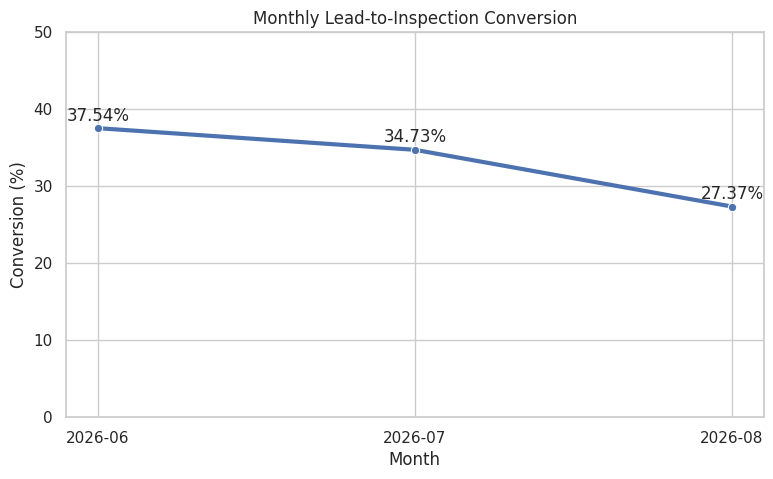

In [114]:
plt.figure(figsize=(9, 5))

sns.lineplot(
    data=monthly,
    x="lead_month",
    y="conversion_pct",
    marker="o",
    linewidth=3
)

plt.title("Monthly Lead-to-Inspection Conversion")
plt.xlabel("Month")
plt.ylabel("Conversion (%)")
plt.ylim(0, 50)

for _, row in monthly.iterrows():
    plt.text(
        row["lead_month"],
        row["conversion_pct"] + 1,
        f'{row["conversion_pct"]:.2f}%',
        ha="center"
    )

plt.show()

In [115]:
city_leads = (
    leads_period
    .groupby("city")
    .agg(
        leads=("lead_id", "nunique")
    )
    .reset_index()
)

city_inspections = (
    inspections_dedup[
        inspections_dedup["lead_id"].isin(
            leads_period["lead_id"]
        )
    ]
    .merge(
        leads_period[
            ["lead_id", "city"]
        ].drop_duplicates("lead_id"),
        on="lead_id",
        how="left"
    )
    .groupby("city")
    .agg(
        inspected_leads=("lead_id", "nunique")
    )
    .reset_index()
)

city_summary = city_leads.merge(
    city_inspections,
    on="city",
    how="left"
)

city_summary["inspected_leads"] = (
    city_summary["inspected_leads"]
    .fillna(0)
)

city_summary["conversion_pct"] = (
    city_summary["inspected_leads"]
    / city_summary["leads"]
    * 100
)

city_summary = city_summary.sort_values(
    "conversion_pct",
    ascending=True
)

display(city_summary)

,city,leads,inspected_leads,conversion_pct
8,Lucknow,3694,952,25.771521
7,LUCKNOW,312,83,26.602564
10,Pune,6510,2021,31.044547
6,Jaipur,4752,1484,31.228956
4,Hyderabad,7424,2326,31.330819
11,delhi ncr,1186,384,32.377740
9,PUNE,569,187,32.864675
3,HYDERABAD,676,224,33.136095
5,JAIPUR,434,146,33.640553
0,BENGALURU,952,332,34.873950


/tmp/ipykernel_1595/2584690500.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


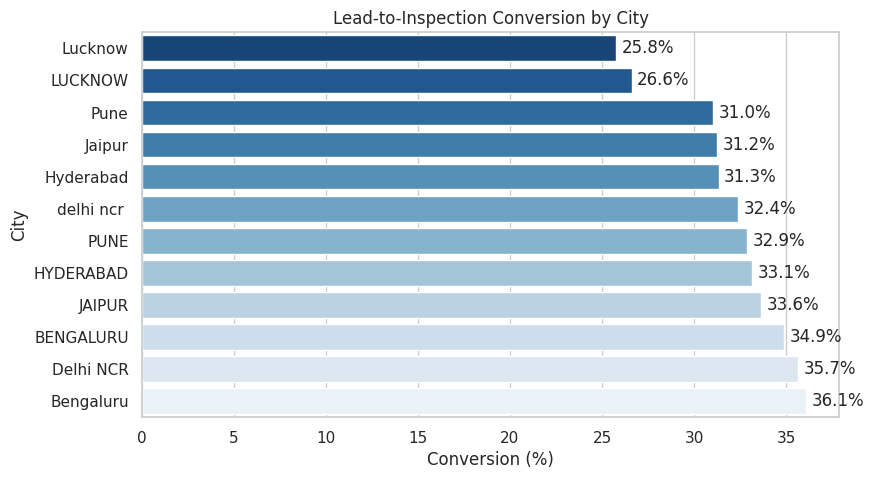

In [116]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=city_summary,
    x="conversion_pct",
    y="city",
    palette="Blues_r"
)

plt.title("Lead-to-Inspection Conversion by City")
plt.xlabel("Conversion (%)")
plt.ylabel("City")

for index, value in enumerate(
    city_summary["conversion_pct"]
):
    plt.text(
        value + 0.3,
        index,
        f"{value:.1f}%",
        va="center"
    )

plt.show()

In [117]:
offers_revision = offers_clean.merge(
    revisions_clean[
        ["inspection_id", "revision_pct"]
    ].drop_duplicates("inspection_id"),
    on="inspection_id",
    how="left"
)

offers_revision["revision_bucket"] = pd.cut(
    offers_revision["revision_pct"],
    bins=[-0.01, 0, 5, 10, 20, 100],
    labels=[
        "No revision",
        "0-5%",
        "5-10%",
        "10-20%",
        "20%+"
    ]
)

revision_summary = (
    offers_revision
    .groupby("revision_bucket", observed=False)
    .agg(
        offers=("inspection_id", "count"),
        purchase_rate=("purchased", "mean")
    )
    .reset_index()
)

revision_summary["purchase_rate_pct"] = (
    revision_summary["purchase_rate"] * 100
)

display(revision_summary)

,revision_bucket,offers,purchase_rate,purchase_rate_pct
0,No revision,2777,0.695355,69.535470
1,0-5%,1829,0.552214,55.221432
2,5-10%,1613,0.342219,34.221947
3,10-20%,1228,0.184853,18.485342
4,20%+,929,0.128095,12.809473


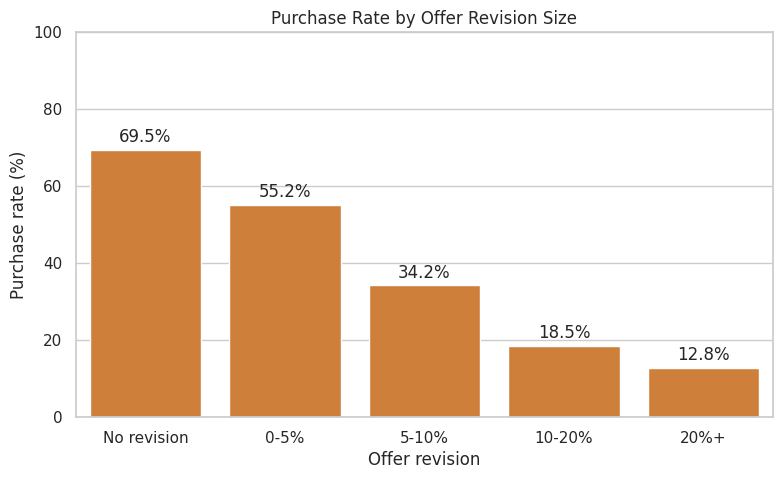

In [119]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=revision_summary,
    x="revision_bucket",
    y="purchase_rate_pct",
    color="#E67E22"
)

plt.title("Purchase Rate by Offer Revision Size")
plt.xlabel("Offer revision")
plt.ylabel("Purchase rate (%)")
plt.ylim(0, 100)

for index, value in enumerate(
    revision_summary["purchase_rate_pct"]
):
    plt.text(
        index,
        value + 2,
        f"{value:.1f}%",
        ha="center"
    )

plt.show()

In [120]:
booked_leads = set(
    appointments_clean["lead_id"]
)

attempt_analysis = calls_clean.copy()

attempt_analysis["booked"] = (
    attempt_analysis["lead_id"]
    .isin(booked_leads)
    .astype(int)
)

attempt_analysis["attempt_bucket"] = pd.cut(
    attempt_analysis["call_attempts"],
    bins=[-1, 1, 2, 3, 5, 10, np.inf],
    labels=[
        "0-1",
        "2",
        "3",
        "4-5",
        "6-10",
        "11+"
    ]
)

attempt_summary = (
    attempt_analysis
    .groupby("attempt_bucket", observed=False)
    .agg(
        leads=("lead_id", "count"),
        booking_rate=("booked", "mean")
    )
    .reset_index()
)

attempt_summary["booking_rate_pct"] = (
    attempt_summary["booking_rate"] * 100
)

display(attempt_summary)

,attempt_bucket,leads,booking_rate,booking_rate_pct
0,0-1,3779,0.436359,43.635883
1,2,9941,0.445629,44.562921
2,3,12635,0.437831,43.783142
3,4-5,18246,0.424860,42.486024
4,6-10,6211,0.352600,35.260023
5,11+,0,NaN,NaN


# #PART B - SQL

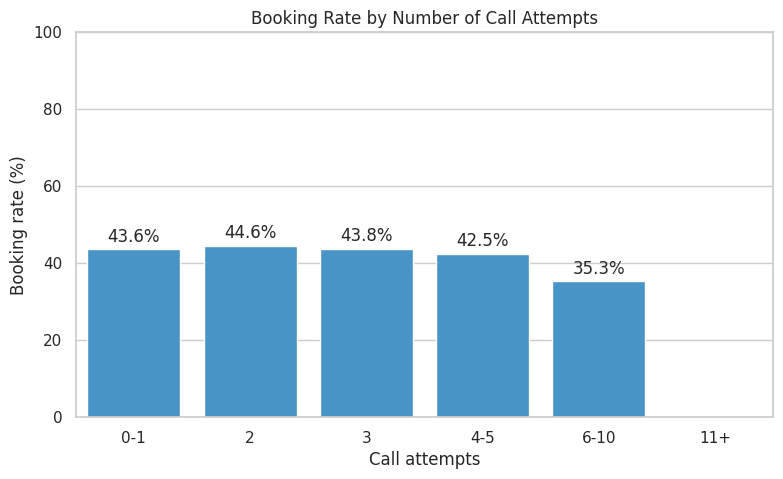

In [122]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=attempt_summary,
    x="attempt_bucket",
    y="booking_rate_pct",
    color="#3498DB"
)

plt.title("Booking Rate by Number of Call Attempts")
plt.xlabel("Call attempts")
plt.ylabel("Booking rate (%)")
plt.ylim(0, 100)

for index, value in enumerate(
    attempt_summary["booking_rate_pct"]
):
    plt.text(
        index,
        value + 2,
        f"{value:.1f}%",
        ha="center"
    )

plt.show()

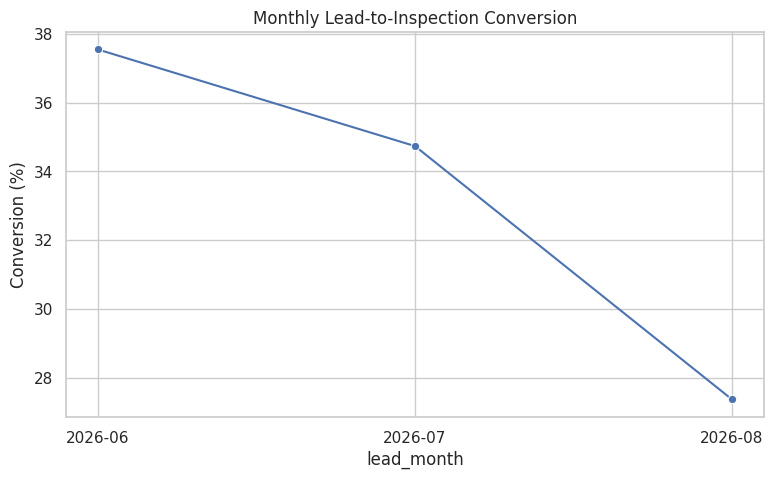

In [123]:
plt.figure(figsize=(9, 5))
sns.lineplot(
    data=monthly,
    x="lead_month",
    y="conversion_pct",
    marker="o"
)
plt.title("Monthly Lead-to-Inspection Conversion")
plt.ylabel("Conversion (%)")
plt.savefig(
    "monthly_conversion.png",
    dpi=200,
    bbox_inches="tight"
)
plt.show()

In [94]:
!pip install duckdb

In [95]:
import duckdb

con = duckdb.connect()

con.register("leads", leads_clean)
con.register("inspections", inspections_clean)
con.register("inspections_dedup", inspections_dedup)
con.register("appointments", appointments_clean)
con.register("calls", calls_clean)
con.register("inspectors", inspectors)
con.register("revisions", revisions_clean)
con.register("offers", offers_clean)
con.register("finance", finance)

print("All datasets registered in DuckDB.")

All datasets registered in DuckDB.


#B1 — Daily conversion by city with 7-day rolling average

In [96]:
query_b1 = """
WITH daily_leads AS (
    SELECT
        CAST(created_at AS DATE) AS activity_date,
        city,
        COUNT(DISTINCT lead_id) AS lead_count
    FROM leads
    WHERE created_at >= '2026-06-01'
      AND created_at < '2026-09-01'
    GROUP BY 1, 2
),

daily_inspections AS (
    SELECT
        CAST(completed_ist AS DATE) AS activity_date,
        l.city,
        COUNT(DISTINCT i.inspection_id) AS inspection_count
    FROM inspections_dedup i
    JOIN leads l
      ON i.lead_id = l.lead_id
    WHERE completed_ist >= '2026-06-01'
      AND completed_ist < '2026-09-01'
    GROUP BY 1, 2
),

daily_metrics AS (
    SELECT
        COALESCE(l.activity_date, i.activity_date) AS activity_date,
        COALESCE(l.city, i.city) AS city,
        COALESCE(l.lead_count, 0) AS lead_count,
        COALESCE(i.inspection_count, 0) AS inspection_count
    FROM daily_leads l
    FULL OUTER JOIN daily_inspections i
      ON l.activity_date = i.activity_date
     AND l.city = i.city
)

SELECT
    activity_date,
    city,
    lead_count,
    inspection_count,
    ROUND(
        100.0 * inspection_count
        / NULLIF(lead_count, 0),
        2
    ) AS conversion_pct,

    ROUND(
        AVG(
            100.0 * inspection_count
            / NULLIF(lead_count, 0)
        ) OVER (
            PARTITION BY city
            ORDER BY activity_date
            ROWS BETWEEN 6 PRECEDING AND CURRENT ROW
        ),
        2
    ) AS rolling_7_day_conversion_pct

FROM daily_metrics
ORDER BY activity_date, city;
"""

b1_result = con.execute(query_b1).df()
display(b1_result.head(20))

,activity_date,city,lead_count,inspection_count,conversion_pct,rolling_7_day_conversion_pct
0,2026-06-01,BENGALURU,9,0,0.00,0.00
1,2026-06-01,Bengaluru,127,15,11.81,11.81
2,2026-06-01,Delhi NCR,148,23,15.54,15.54
3,2026-06-01,HYDERABAD,5,3,60.00,60.00
4,2026-06-01,Hyderabad,91,11,12.09,12.09
5,2026-06-01,JAIPUR,7,0,0.00,0.00
6,2026-06-01,Jaipur,55,5,9.09,9.09
7,2026-06-01,LUCKNOW,4,0,0.00,0.00
8,2026-06-01,Lucknow,28,3,10.71,10.71
9,2026-06-01,PUNE,7,1,14.29,14.29


#B2 — Inspector performance and anomaly flag

In [97]:
query_b2 = """
WITH inspector_metrics AS (
    SELECT
        i.inspector_id,

        COUNT(DISTINCT i.inspection_id)
            AS inspection_count,

        MEDIAN(i.duration_min)
            AS median_duration_min,

        MEDIAN(i.distance_km)
            AS median_distance_km,

        COUNT(DISTINCT r.inspection_id) * 1.0
        / NULLIF(COUNT(DISTINCT i.inspection_id), 0)
            AS offer_rate,

        AVG(
            CASE
                WHEN i.duration_min < 5
                 AND i.distance_km > 20
                THEN 1.0
                ELSE 0.0
            END
        ) AS suspicious_rate

    FROM inspections i

    LEFT JOIN revisions r
      ON i.inspection_id = r.inspection_id

    GROUP BY i.inspector_id
)

SELECT
    m.inspector_id,
    m.city,
    m.employment_type,

    x.inspection_count,
    ROUND(x.median_duration_min, 2)
        AS median_duration_min,
    ROUND(x.median_distance_km, 2)
        AS median_distance_km,
    ROUND(100.0 * x.offer_rate, 2)
        AS offer_rate_pct,
    ROUND(100.0 * x.suspicious_rate, 2)
        AS suspicious_rate_pct,

    CASE
        WHEN x.suspicious_rate >= 0.05
          OR x.median_duration_min < 10
          OR x.median_distance_km > 20
        THEN 'REVIEW'
        ELSE 'OK'
    END AS anomaly_flag

FROM inspector_metrics x
JOIN inspectors m
  ON x.inspector_id = m.inspector_id

ORDER BY anomaly_flag DESC, inspection_count DESC;
"""

b2_result = con.execute(query_b2).df()
display(b2_result.head(20))

,inspector_id,city,employment_type,inspection_count,median_duration_min,median_distance_km,offer_rate_pct,suspicious_rate_pct,anomaly_flag
0,CJ1084,Bengaluru,In-house,124,35.0,36.29,53.23,0.0,REVIEW
1,CJ1087,Bengaluru,In-house,112,37.0,38.90,43.75,0.0,REVIEW
2,CJ1043,Delhi NCR,In-house,110,35.0,38.68,50.00,0.0,REVIEW
3,CJ1080,Bengaluru,In-house,108,33.5,38.84,55.56,0.0,REVIEW
4,CJ1096,Bengaluru,In-house,108,36.5,37.98,52.78,0.0,REVIEW
5,CJ1095,Bengaluru,In-house,107,37.5,36.57,46.73,0.0,REVIEW
6,CJ1012,Delhi NCR,In-house,107,33.0,33.51,42.06,0.0,REVIEW
7,CJ1072,Bengaluru,In-house,104,38.0,33.75,42.31,0.0,REVIEW
8,CJ1005,Delhi NCR,In-house,104,40.0,31.69,52.88,0.0,REVIEW
9,CJ1019,Delhi NCR,In-house,103,36.0,37.94,46.60,0.0,REVIEW


#B3 — Reconcile the operational inspection count to Finance

In [98]:
query_b3 = """
WITH monthly_operational AS (
    SELECT
        DATE_TRUNC(
            'month',
            completed_ist
        ) AS month,

        COUNT(*) AS raw_rows,

        COUNT(DISTINCT inspection_id)
            AS distinct_inspection_ids,

        COUNT(DISTINCT lead_id)
            AS distinct_leads

    FROM inspections

    WHERE completed_ist >= '2026-06-01'
      AND completed_ist < '2026-10-01'

    GROUP BY 1
),

finance_counts AS (
    SELECT
        CAST(
            CAST(month AS VARCHAR) || '-01'
            AS DATE
        ) AS month,

        finance_inspection_count

    FROM finance
)

SELECT
    f.month,
    'Raw inspection rows' AS component,
    o.raw_rows AS row_count
FROM finance_counts f
LEFT JOIN monthly_operational o
  ON f.month = o.month

UNION ALL

SELECT
    f.month,
    'Duplicate inspection rows',
    o.raw_rows - o.distinct_inspection_ids
FROM finance_counts f
LEFT JOIN monthly_operational o
  ON f.month = o.month

UNION ALL

SELECT
    f.month,
    'Distinct inspection IDs',
    o.distinct_inspection_ids
FROM finance_counts f
LEFT JOIN monthly_operational o
  ON f.month = o.month

UNION ALL

SELECT
    f.month,
    'Distinct inspected leads',
    o.distinct_leads
FROM finance_counts f
LEFT JOIN monthly_operational o
  ON f.month = o.month

UNION ALL

SELECT
    f.month,
    'Finance count',
    f.finance_inspection_count
FROM finance_counts f

UNION ALL

SELECT
    f.month,
    'Finance minus distinct inspection IDs',
    f.finance_inspection_count
        - o.distinct_inspection_ids
FROM finance_counts f
LEFT JOIN monthly_operational o
  ON f.month = o.month

ORDER BY month, component;
"""

b3_result = con.execute(query_b3).df()
display(b3_result)

,month,component,row_count
0,2026-06-01,Distinct inspected leads,6382
1,2026-06-01,Distinct inspection IDs,6382
2,2026-06-01,Duplicate inspection rows,124
3,2026-06-01,Finance count,6458
4,2026-06-01,Finance minus distinct inspection IDs,76
5,2026-06-01,Raw inspection rows,6506
6,2026-07-01,Distinct inspected leads,5520
7,2026-07-01,Distinct inspection IDs,5520
8,2026-07-01,Duplicate inspection rows,83
9,2026-07-01,Finance count,5396


#B4 — Lead cohort table

In [99]:
query_b4 = """
WITH first_inspection AS (
    SELECT
        lead_id,
        MIN(started_ist) AS first_inspection_at
    FROM inspections_dedup
    GROUP BY lead_id
),

lead_cohorts AS (
    SELECT
        lead_id,
        DATE_TRUNC('week', created_at) AS cohort_week,
        created_at
    FROM leads
    WHERE created_at >= '2026-06-01'
      AND created_at < '2026-09-01'
)

SELECT
    l.cohort_week,
    COUNT(*) AS leads,

    ROUND(
        100.0 * SUM(
            CASE
                WHEN DATE_DIFF(
                    'hour',
                    l.created_at,
                    i.first_inspection_at
                ) <= 24
                THEN 1
                ELSE 0
            END
        ) / COUNT(*),
        2
    ) AS inspected_within_24h_pct,

    ROUND(
        100.0 * SUM(
            CASE
                WHEN DATE_DIFF(
                    'hour',
                    l.created_at,
                    i.first_inspection_at
                ) <= 48
                THEN 1
                ELSE 0
            END
        ) / COUNT(*),
        2
    ) AS inspected_within_48h_pct,

    ROUND(
        100.0 * SUM(
            CASE
                WHEN DATE_DIFF(
                    'day',
                    l.created_at,
                    i.first_inspection_at
                ) <= 7
                THEN 1
                ELSE 0
            END
        ) / COUNT(*),
        2
    ) AS inspected_within_7_days_pct

FROM lead_cohorts l
LEFT JOIN first_inspection i
  ON l.lead_id = i.lead_id

GROUP BY l.cohort_week
ORDER BY l.cohort_week;
"""

b4_result = con.execute(query_b4).df()
display(b4_result)

,cohort_week,leads,inspected_within_24h_pct,inspected_within_48h_pct,inspected_within_7_days_pct
0,2026-06-01,4062,19.87,34.74,37.42
1,2026-06-08,4111,20.46,35.66,38.75
2,2026-06-15,4212,19.33,33.86,36.59
3,2026-06-22,4061,19.18,33.98,37.13
4,2026-06-29,3571,20.30,34.39,37.16
5,2026-07-06,3382,20.17,33.94,36.46
6,2026-07-13,3496,18.94,32.92,35.01
7,2026-07-20,3614,17.21,31.32,33.70
8,2026-07-27,4094,17.24,28.53,30.48
9,2026-08-03,4529,14.35,26.10,28.48


# #Part C — Product and inference

#C1 — Analyze offer revisions

In [100]:
# Add city and car information
revision_analysis = offers_with_revision.merge(
    leads_clean[
        ["lead_id", "city", "car_year"]
    ],
    on="lead_id",
    how="left"
)

# Create revision categories
revision_analysis["revision_bucket"] = pd.cut(
    revision_analysis["revision_pct"],
    bins=[-0.01, 0, 5, 10, 20, 100],
    labels=[
        "No revision",
        "0-5%",
        "5-10%",
        "10-20%",
        "20%+"
    ]
)

revision_summary = (
    revision_analysis
    .groupby("revision_bucket", observed=False)
    .agg(
        offer_rows=("inspection_id", "count"),
        purchases=("purchased", "sum"),
        purchase_rate=("purchased", "mean"),
        average_offer=("offer_price", "mean")
    )
    .reset_index()
)

revision_summary["purchase_rate_pct"] = (
    revision_summary["purchase_rate"] * 100
)

display(revision_summary)

,revision_bucket,offer_rows,purchases,purchase_rate,average_offer,purchase_rate_pct
0,No revision,2777,1931,0.695355,262755.484696,69.535470
1,0-5%,1829,1010,0.552214,263286.510662,55.221432
2,5-10%,1613,552,0.342219,260807.843769,34.221947
3,10-20%,1228,227,0.184853,262037.385179,18.485342
4,20%+,929,119,0.128095,263768.030140,12.809473


#C2 — Find where the problem is concentrated

In [101]:
city_revision_summary = (
    revision_analysis
    .groupby(["city", "revision_bucket"], observed=False)
    .agg(
        offers=("inspection_id", "count"),
        purchases=("purchased", "sum"),
        purchase_rate=("purchased", "mean")
    )
    .reset_index()
)

city_revision_summary["purchase_rate_pct"] = (
    city_revision_summary["purchase_rate"] * 100
)

display(
    city_revision_summary.sort_values(
        "purchase_rate_pct"
    )
)

,city,revision_bucket,offers,purchases,purchase_rate,purchase_rate_pct
19,HYDERABAD,20%+,13,0,0.000000,0.000000
38,LUCKNOW,10-20%,1,0,0.000000,0.000000
39,LUCKNOW,20%+,2,0,0.000000,0.000000
49,PUNE,20%+,15,1,0.066667,6.666667
34,Jaipur,20%+,90,9,0.100000,10.000000
14,Delhi NCR,20%+,258,28,0.108527,10.852713
9,Bengaluru,20%+,169,20,0.118343,11.834320
44,Lucknow,20%+,47,6,0.127660,12.765957
58,delhi ncr,10-20%,23,3,0.130435,13.043478
37,LUCKNOW,5-10%,7,1,0.142857,14.285714


#C3 — Analyze revision reasons

In [102]:
reason_analysis = revision_analysis.merge(
    revisions_clean[
        ["inspection_id", "revision_reason"]
    ],
    on="inspection_id",
    how="left"
)

reason_summary = (
    reason_analysis
    .groupby("revision_reason")
    .agg(
        offers=("inspection_id", "count"),
        purchases=("purchased", "sum"),
        purchase_rate=("purchased", "mean"),
        average_revision=("revision_pct", "mean")
    )
    .reset_index()
)

reason_summary["purchase_rate_pct"] = (
    reason_summary["purchase_rate"] * 100
)

display(
    reason_summary.sort_values(
        "purchase_rate_pct"
    )
)

,revision_reason,offers,purchases,purchase_rate,average_revision,purchase_rate_pct
2,Document issue,1622,734,0.452528,6.183107,45.252774
1,Condition mismatch,3587,1643,0.458043,6.194592,45.804293
3,Market correction,2193,1012,0.461468,6.155039,46.146831
0,Accident history,974,450,0.462012,6.370637,46.201232


#C4 — Analyze call attempts versus booking

In [103]:
#Use the existence of an appointment as the booking indicator
booked_leads = set(
    appointments_clean["lead_id"].dropna()
)

call_booking = calls_clean.copy()

call_booking["booked"] = (
    call_booking["lead_id"].isin(booked_leads)
    .astype(int)
)

call_booking["attempt_bucket"] = pd.cut(
    call_booking["call_attempts"],
    bins=[-1, 1, 2, 3, 5, 10, np.inf],
    labels=[
        "0-1",
        "2",
        "3",
        "4-5",
        "6-10",
        "11+"
    ]
)

attempt_summary = (
    call_booking
    .groupby("attempt_bucket", observed=False)
    .agg(
        leads=("lead_id", "count"),
        booked_leads=("booked", "sum"),
        booking_rate=("booked", "mean"),
        average_talk_time=("talk_time_sec", "mean")
    )
    .reset_index()
)

attempt_summary["booking_rate_pct"] = (
    attempt_summary["booking_rate"] * 100
)

display(attempt_summary)

,attempt_bucket,leads,booked_leads,booking_rate,average_talk_time,booking_rate_pct
0,0-1,3779,1649,0.436359,151.002382,43.635883
1,2,9941,4430,0.445629,151.473795,44.562921
2,3,12635,5532,0.437831,151.156074,43.783142
3,4-5,18246,7752,0.424860,151.260660,42.486024
4,6-10,6211,2190,0.352600,139.727258,35.260023
5,11+,0,0,NaN,NaN,NaN


In [104]:
revision_summary.to_csv(
    "part_c_revision_summary.csv",
    index=False
)

city_revision_summary.to_csv(
    "part_c_city_revision_summary.csv",
    index=False
)

attempt_summary.to_csv(
    "part_c_attempt_summary.csv",
    index=False
)

# #Part D — Excel

In [105]:
!pip install XlsxWriter

#Calculate default assumptions from the data

In [106]:
# Leads
total_leads = len(leads_period)

# Connected leads
connected_leads = calls_clean[
    calls_clean["connected"] == 1
]["lead_id"].nunique()

# Booked leads
booked_leads = appointments_clean[
    "lead_id"
].nunique()

# Completed inspections
completed_inspections = appointments_clean[
    appointments_clean["status"] == "Completed"
]["lead_id"].nunique()

# Purchases
total_purchases = offers_clean[
    offers_clean["purchased"] == 1
]["lead_id"].nunique()

# Average contribution
offers_model = offers_clean.copy()

offers_model["contribution"] = (
    offers_model["resale_price"]
    - offers_model["offer_price"]
    - offers_model["refurb_cost"]
    - offers_model["tow_cost"]
)

average_contribution = (
    offers_model.loc[
        offers_model["purchased"] == 1,
        "contribution"
    ].mean()
)

# Marketing cost per lead
marketing_total = marketing_spend_clean[
    (marketing_spend_clean["date"] >= "2026-06-01")
    & (marketing_spend_clean["date"] < "2026-09-01")
]["spend_inr"].sum()

cost_per_lead = marketing_total / total_leads

# Default assumptions
lead_to_call = connected_leads / total_leads
call_to_appointment = booked_leads / max(connected_leads, 1)
appointment_show_up = (
    completed_inspections / max(booked_leads, 1)
)
inspection_to_purchase = (
    total_purchases / max(completed_inspections, 1)
)

print("Lead-to-call:", lead_to_call)
print("Call-to-appointment:", call_to_appointment)
print("Appointment show-up:", appointment_show_up)
print("Inspection-to-purchase:", inspection_to_purchase)
print("Average contribution:", average_contribution)
print("Cost per lead:", cost_per_lead)

Lead-to-call: 0.7171731087144769
Call-to-appointment: 0.5914491918443512
Appointment show-up: 0.8248503688581637
Inspection-to-purchase: 0.3484643941950726
Average contribution: 22254.69281678773
Cost per lead: 1024.4899630008658


#Create the Excel model

In [107]:
import xlsxwriter

output_file = "Cars24_unit_economics_model.xlsx"

workbook = xlsxwriter.Workbook(output_file)
worksheet = workbook.add_worksheet("Unit Economics")

# Formats
title_format = workbook.add_format({
    "bold": True,
    "font_size": 16,
    "bg_color": "#1F4E78",
    "font_color": "white"
})

header_format = workbook.add_format({
    "bold": True,
    "bg_color": "#D9EAF7",
    "border": 1
})

input_format = workbook.add_format({
    "bg_color": "#FFF2CC",
    "border": 1,
    "num_format": "0.0%"
})

number_input_format = workbook.add_format({
    "bg_color": "#FFF2CC",
    "border": 1,
    "num_format": "₹#,##0"
})

number_format = workbook.add_format({
    "border": 1,
    "num_format": "₹#,##0"
})

percent_format = workbook.add_format({
    "border": 1,
    "num_format": "0.0%"
})

integer_format = workbook.add_format({
    "border": 1,
    "num_format": "#,##0"
})

# Column widths
worksheet.set_column("A:A", 34)
worksheet.set_column("B:B", 18)
worksheet.set_column("C:C", 45)

worksheet.write("A1", "Cars24 Supply Unit Economics", title_format)
worksheet.write("A3", "Editable Inputs", header_format)
worksheet.write("B3", "Value", header_format)
worksheet.write("C3", "Notes", header_format)

inputs = [
    ("Leads", 1000, "Model uses 1,000 leads"),
    ("Lead-to-call conversion", lead_to_call, "From call logs"),
    ("Call-to-appointment conversion", call_to_appointment, "Booked leads / connected leads"),
    ("Appointment show-up rate", appointment_show_up, "Completed appointments / booked leads"),
    ("Inspection-to-purchase rate", inspection_to_purchase, "Purchases / completed inspections"),
    ("Inspector cost per inspection", 450, "Editable assumption"),
    ("Vendor commission", 0.00, "No source value provided; editable"),
    ("Average contribution per car", average_contribution, "Resale less offer, refurb and tow"),
    ("Cost per lead", cost_per_lead, "Marketing spend / leads"),
]

start_row = 3

for i, (label, value, note) in enumerate(inputs):
    row = start_row + i + 1

    worksheet.write(row, 0, label, header_format)

    if isinstance(value, float) and value < 1:
        worksheet.write(row, 1, value, input_format)
    else:
        worksheet.write(row, 1, value, number_input_format)

    worksheet.write(row, 2, note)

# Output section
output_start = 15

worksheet.write(output_start, 0, "Outputs", header_format)
worksheet.write(output_start, 1, "Formula result", header_format)

worksheet.write(output_start + 1, 0, "Expected inspections")
worksheet.write_formula(
    output_start + 1,
    1,
    "=B4*B5*B6*B7",
    integer_format
)

worksheet.write(output_start + 2, 0, "Expected purchases")
worksheet.write_formula(
    output_start + 2,
    1,
    "=B16*B8",
    integer_format
)

worksheet.write(output_start + 3, 0, "Gross contribution")
worksheet.write_formula(
    output_start + 3,
    1,
    "=B17*B11*(1-B10)",
    number_format
)

worksheet.write(output_start + 4, 0, "Inspection cost")
worksheet.write_formula(
    output_start + 4,
    1,
    "=B16*B9",
    number_format
)

worksheet.write(output_start + 5, 0, "Lead acquisition cost")
worksheet.write_formula(
    output_start + 5,
    1,
    "=B4*B12",
    number_format
)

worksheet.write(output_start + 6, 0, "Contribution per 1,000 leads")
worksheet.write_formula(
    output_start + 6,
    1,
    "=B18-B19-B20",
    number_format
)

worksheet.write(output_start + 7, 0, "Break-even lead-to-inspection conversion")
worksheet.write_formula(
    output_start + 7,
    1,
    "=B12/(B8*B11*(1-B10)-B9)",
    percent_format
)

# Sensitivity table
sensitivity_row = 26

worksheet.write(
    sensitivity_row,
    0,
    "Sensitivity: Conversion vs Contribution per Car",
    header_format
)

worksheet.write(
    sensitivity_row + 1,
    0,
    "Conversion / Contribution",
    header_format
)

contribution_values = [
    10000, 15000, 20000, 25000, 30000, 40000, 50000
]

conversion_values = [
    0.10, 0.15, 0.20, 0.25,
    0.30, 0.35, 0.40, 0.45, 0.50
]

for col, value in enumerate(contribution_values, start=1):
    worksheet.write(
        sensitivity_row + 1,
        col,
        value,
        number_input_format
    )

for row, conversion in enumerate(
    conversion_values,
    start=sensitivity_row + 2
):
    worksheet.write(row, 0, conversion, input_format)

    for col in range(1, len(contribution_values) + 1):
        excel_col = chr(66 + col - 1)
        formula = (
            f"=1000*$A{row + 1}*"
            f"$B$8*{excel_col}${sensitivity_row + 2}"
            f"*(1-$B$10)"
            f"-1000*$A{row + 1}*$B$9"
            f"-1000*$B$12"
        )

        worksheet.write_formula(
            row,
            col,
            formula,
            number_format
        )

workbook.close()

print(f"Created: {output_file}")

Created: Cars24_unit_economics_model.xlsx


In [108]:
from google.colab import files

files.download("Cars24_unit_economics_model.xlsx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>